# 1. Introduction
#### Modélisation avec ARIMA et SARIMA

**Objectif**

Cette étape consiste à utiliser un modèle ARIMA afin de prédire les futures commandes de carburant à partir des séries temporelles historiques.

Le modèle ARIMA permet de capturer :
- les tendances ;
- les dépendances temporelles ;
- les comportements chronologiques des commandes.

## 2. Importation des Bibliothèques

In [5]:
# IMPORTATION DES BIBLIOTHEQUES

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA

from statsmodels.tsa.stattools import adfuller

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

## 3. Chargement des commandes propres

In [13]:
# CHARGEMENT DU DATASET

df = pd.read_excel("../data/propre/commandes_propres.xlsx")

print(df.shape)

display(df.head())

(34150, 13)


,Date comptabilisation,N° article,N° origine,N° contact origine,Quantité facturée,Code Produit,Type document,NOM CLIENT,Nom sous compte,TYPE,STATUT,Code Station,GROUPE TYPE
0,2020-01-13,A0001,C1234,CC2616,5000,PROD-BLANC,Expédition vente,GIBLAND COMPAGNY,STATION ATTAKE,CODO,Fonctionnelle,ST0049,STATION
1,2020-01-13,A0002,C1234,CC2616,4000,PROD-BLANC,Expédition vente,GIBLAND COMPAGNY,STATION ATTAKE,CODO,Fonctionnelle,ST0049,STATION
2,2020-01-13,A0001,C1249,CC2650,1000,PROD-BLANC,Expédition vente,TONI ET FILS,STATION NDALI,DODO,Fonctionnelle,ST0092,STATION
3,2020-01-13,A0002,C1249,CC2650,16000,PROD-BLANC,Expédition vente,TONI ET FILS,STATION NDALI,DODO,Fonctionnelle,ST0092,STATION
4,2020-01-13,A0001,C1233,CC2614,5000,PROD-BLANC,Expédition vente,AYODELE BUSINESS,STATION OUIDAH,CODO,Fonctionnelle,ST0016,STATION


# 4. Conversion des dates
ARIMA travaille uniquement avec des séries temporelles ordonnées.

In [195]:
# CONVERSION DATES

df["Date comptabilisation"] = pd.to_datetime(
    df["Date comptabilisation"]
)

## 5. Sélection d’une station et d’un produit
ARIMA ne gère pas naturellement plusieurs stations simultanément, donc une série = une station + un produit.

In [199]:
# FILTRAGE STATION + PRODUIT


station = "ST0002"
produit = "A0001"

df_station = df[
    (df["Code Station"] == station) &
    (df["N° article"] == produit)
].copy()

print(df_station.shape)

(1158, 13)


## 6. Agrégation journalière

In [201]:
# AGREGATION JOURNALIERE

serie = (
    df_station
    .groupby("Date comptabilisation")
    ["Quantité facturée"]
    .sum()
)

display(serie.head())

Date comptabilisation
2020-03-03    25000
2020-03-13    39000
2020-03-16    26000
2020-03-18     8000
2020-03-19     7000
Name: Quantité facturée, dtype: int64

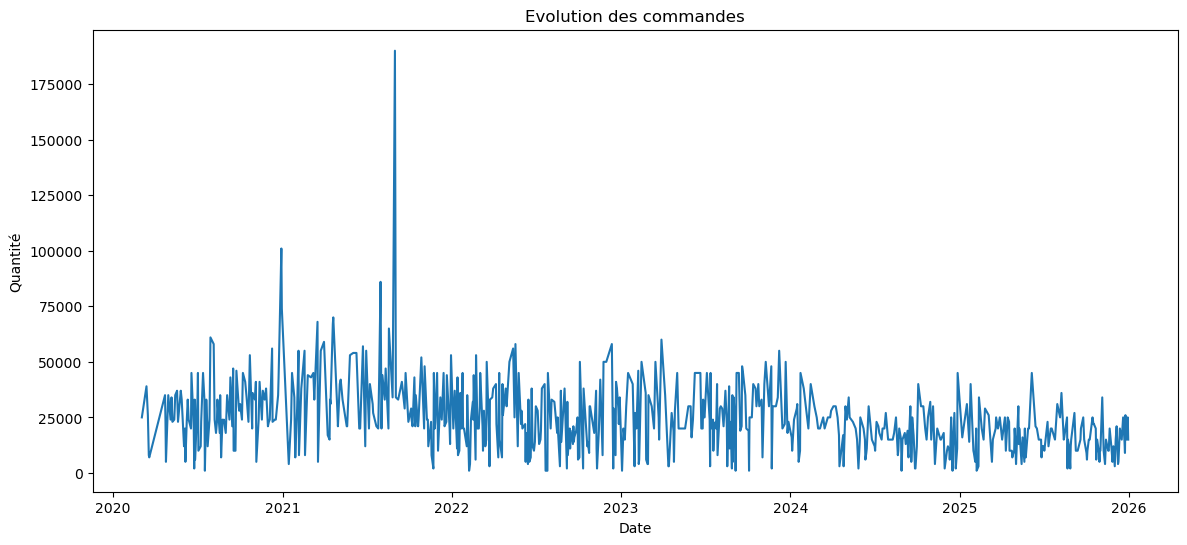

In [203]:
# VISUALISATION

plt.figure(figsize=(14,6))

plt.plot(serie)

plt.title("Evolution des commandes")

plt.xlabel("Date")
plt.ylabel("Quantité")

plt.show()

In [205]:
# TEST ADF

result = adfuller(serie)

print("ADF Statistic :", result[0])
print("p-value :", result[1])

ADF Statistic : -2.8051988871601927
p-value : 0.05753497294531179


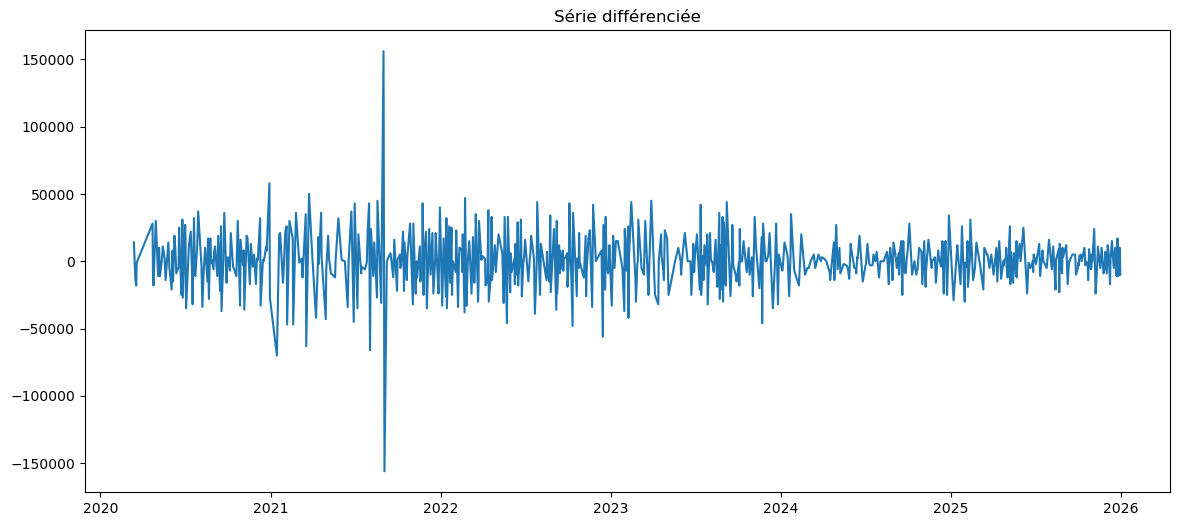

In [209]:
# DIFFERENCIATION

serie_diff = serie.diff().dropna()

plt.figure(figsize=(14,6))

plt.plot(serie_diff)

plt.title("Série différenciée")

plt.show()

## 5. Séparation Train/Test
Mon problème étant temporel, alors il faut :entraîner sur le passé ettester sur le futur.
Sinon : fuite de données et faux résultats.

In [211]:
# TRAIN / TEST

train_size = int(len(serie) * 0.8)

train = serie[:train_size]
test = serie[train_size:]

print(train.shape)
print(test.shape)

(528,)
(132,)


# 6. Construction du modèle ARIMA
Le fameux ARIMA(p,d,q)
Explication des paramètres
p

Nombre de retards.

d

Nombre de différenciations.

q

Partie moyenne mobile.



In [274]:
# MODELE ARIMA

model_arima = ARIMA(
    train,
    order=(1,1,1)
)

model_fit = model_arima.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:      Quantité facturée   No. Observations:                  528
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -5853.655
Date:                Tue, 19 May 2026   AIC                          11713.309
Time:                        16:46:53   BIC                          11726.111
Sample:                             0   HQIC                         11718.321
                                - 528                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0403      0.054     -0.745      0.456      -0.146       0.066
ma.L1         -0.9461      0.019    -48.752      0.000      -0.984      -0.908
sigma2      3.021e+08   7.29e-11   4.14e+18      0.0

C:\Users\ADMIN\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\ADMIN\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\ADMIN\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


## 7. Prédictions
Le modèle tente ici d'estimer les futures commandes

In [276]:
# PREDICTIONS
predictions_arima = model_fit.forecast(
    steps=len(test)
)

print(predictions_arima[:10])

528    16569.790608
529    16305.052588
530    16315.720541
531    16315.290662
532    16315.307985
533    16315.307287
534    16315.307315
535    16315.307314
536    16315.307314
537    16315.307314
Name: predicted_mean, dtype: float64


C:\Users\ADMIN\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\ADMIN\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


## 8. Évaluation des performances

### 8.1 MAE
Le MAE mesure l’erreur moyenne absolue.

In [218]:
# MAE

mae = mean_absolute_error(
    test,
    predictions_arima
)

print("MAE :", mae)

MAE : 7239.3612708121655


### 8.2 RMSE

Pénalise fortement les grosses erreurs.

In [220]:
# RMSE

rmse = np.sqrt(
    mean_squared_error(
        test,
        predictions_arima
    )
)

print("RMSE :", rmse)

RMSE : 8949.15467651329


### 8.3 R2 SCORE

Mesure la qualité globale du modèle.

In [222]:
# R2 SCORE

r2 = r2_score(
    test,
    predictions_arima
)

print("R² :", r2)

R² : -0.005993913212449575


## 9. Comparaison Réel vs Prédit

In [224]:
# REEL VS PREDIT

comparaison = pd.DataFrame({
    "Réel": test.values,
    "Prédit": predictions_arima
})

display(comparaison.head(20))

,Réel,Prédit
528,12000,16569.790608
529,10000,16305.052588
530,6000,16315.720541
531,10000,16315.290662
532,25000,16315.307985
533,1000,16315.307287
534,12000,16315.307315
535,27000,16315.307314
536,2000,16315.307314
537,11000,16315.307314


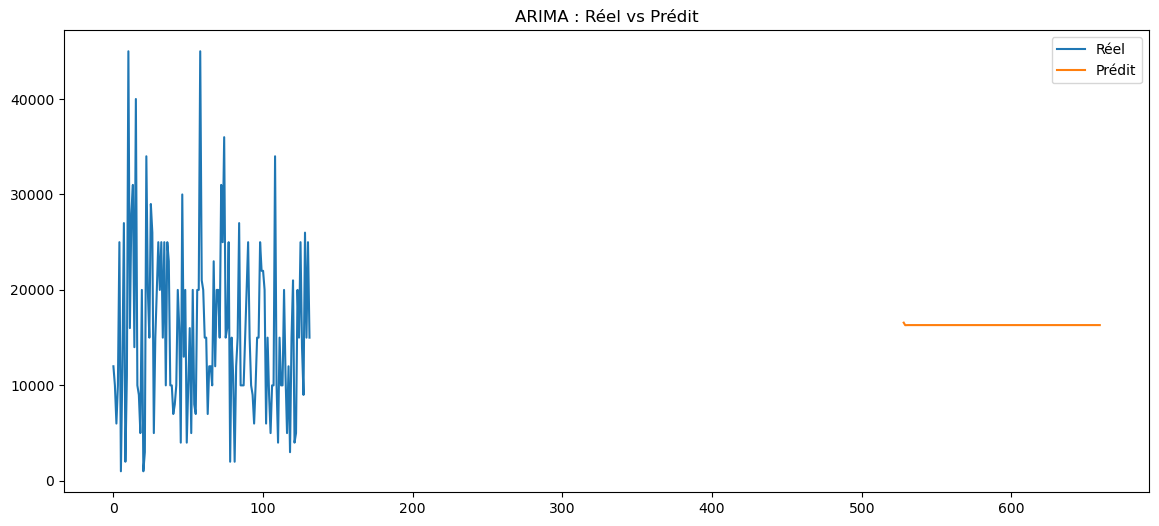

In [234]:
# GRAPHIQUE

plt.figure(figsize=(14,6))

plt.plot(
    test.values,
    label="Réel"
)

plt.plot(
    predictions_arima,
    label="Prédit"
)

plt.legend()

plt.title("ARIMA : Réel vs Prédit")

plt.show()

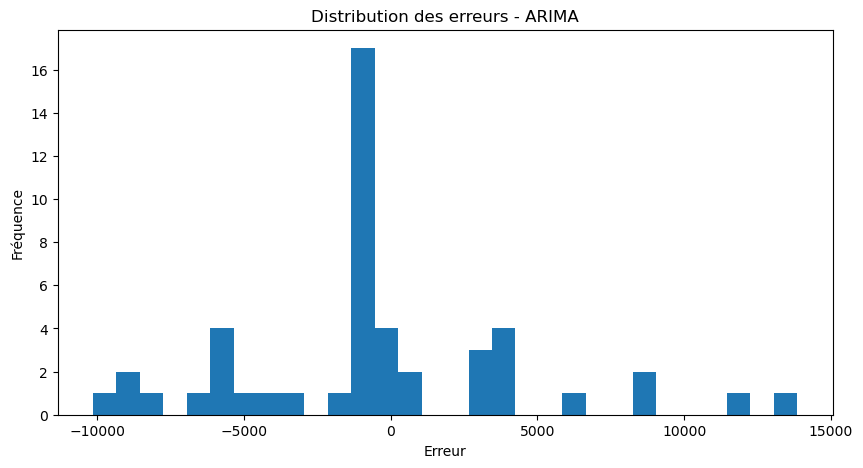

In [136]:
# Distribution des erreurs

errors = test.values - predictions_arima

plt.figure(figsize=(10,5))

plt.hist(errors, bins=30)

plt.title("Distribution des erreurs - ARIMA")

plt.xlabel("Erreur")
plt.ylabel("Fréquence")

plt.show()

### Analyse de la distribution des erreurs


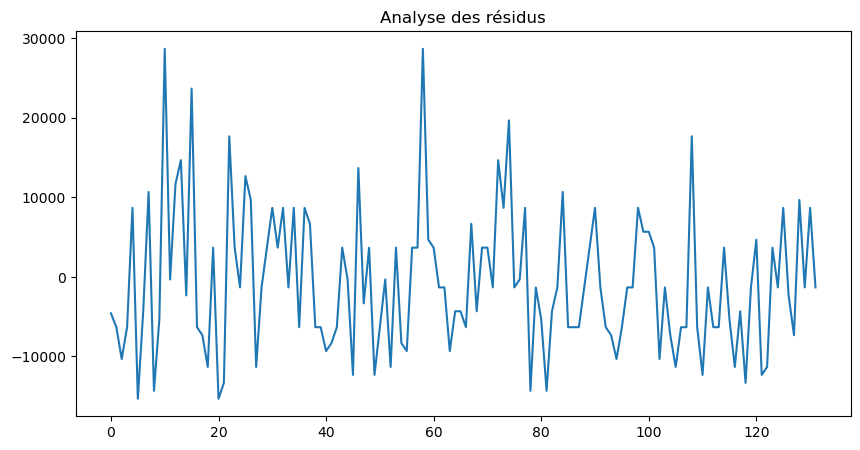

In [236]:
residus = test.values - predictions_arima

plt.figure(figsize=(10,5))

plt.plot(residus.values)

plt.title("Analyse des résidus")

plt.show()

In [238]:
# COMPARAISON avec le Random Forest et xgboost

comparaison = pd.DataFrame({
    "Modele": [
        "Random Forest",
        "XGBoost",
        "ARIMA"
    ],
    "MAE": [
        2702.52,
        2756.39,
        mae
    ],
    "RMSE": [
        3677.12,
        3808.61,
        rmse
    ],
    "R2": [
        0.626,
        0.598,
        r2
    ]
})

display(comparaison)

,Modele,MAE,RMSE,R2
0,Random Forest,2702.520000,3677.120000,0.626000
1,XGBoost,2756.390000,3808.610000,0.598000
2,ARIMA,7239.361271,8949.154677,-0.005994


## MODELE SARIMA

**Objectif**

Cette étape consiste à utiliser un modèle SARIMA afin de prendre en compte :
- les dépendances temporelles ;
- les tendances ;
- les comportements saisonniers des commandes de carburant.

Le modèle SARIMA constitue une extension du modèle ARIMA classique avec intégration de composantes saisonnières.

In [280]:
# AGREGATION HEBDOMADAIRE

serie = (
    df_station
    .groupby("Date comptabilisation")
    ["Quantité facturée"]
    .sum()
)

serie_w = serie.resample("W").sum()

display(serie_w.head())

Date comptabilisation
2020-03-08    25000
2020-03-15    39000
2020-03-22    41000
2020-03-29        0
2020-04-05        0
Freq: W-SUN, Name: Quantité facturée, dtype: int64

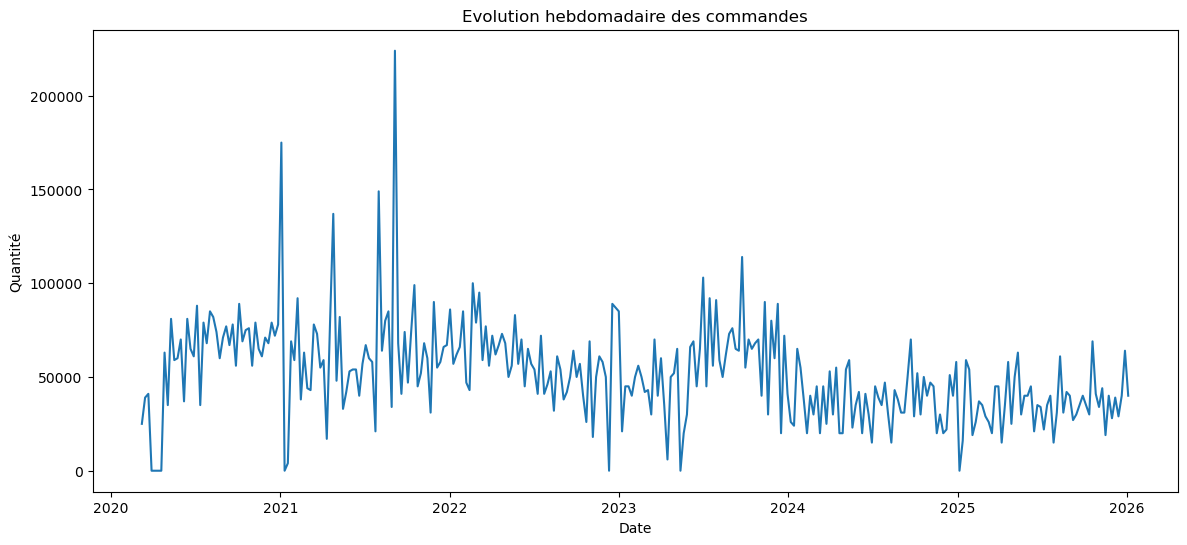

In [282]:
# VISUALISATION

plt.figure(figsize=(14,6))

plt.plot(serie_w)

plt.title("Evolution hebdomadaire des commandes")

plt.xlabel("Date")
plt.ylabel("Quantité")

plt.show()

In [284]:
# TEST ADF
result = adfuller(serie_w.dropna())

print("ADF Statistic :", result[0])
print("p-value :", result[1])

ADF Statistic : -3.6654683491074014
p-value : 0.004625940439536258


In [286]:
# MODELE SARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_sarima = SARIMAX(
    serie_w,

    order=(1,1,1),

    seasonal_order=(1,1,1,12)
)

model_fit = model_sarima.fit()

print(model_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                  Quantité facturée   No. Observations:                  305
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -3392.035
Date:                            Tue, 19 May 2026   AIC                           6794.071
Time:                                    16:49:41   BIC                           6812.455
Sample:                                03-08-2020   HQIC                          6801.435
                                     - 01-04-2026                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1697      0.079     -2.149      0.032      -0.325      -0.015
ma.L1         -0.8093      0.075   

In [288]:
# ENTRAINEMENT

model_sarima = SARIMAX(
    train,

    order=(1,1,1),

    seasonal_order=(1,1,1,4)
)

model_fit = model_sarima.fit()

C:\Users\ADMIN\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\ADMIN\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [290]:
# PREDICTIONS

predictions_sarima = model_fit.forecast(
    steps=len(test)
)

display(predictions_sarima.head())

C:\Users\ADMIN\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\ADMIN\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


528    17466.372240
529    14961.782808
530    16594.631067
531    14406.909022
532    17487.114419
Name: predicted_mean, dtype: float64

In [292]:
mae = mean_absolute_error(
    test,
    predictions_sarima
)

print("MAE :", mae)

MAE : 7173.181165475603


In [294]:
rmse = np.sqrt(
    mean_squared_error(
        test,
        predictions_sarima
    )
)

print("RMSE :", rmse)

RMSE : 8870.236274430843


In [296]:
r2 = r2_score(
    test,
    predictions_sarima
)

print("R² :", r2)

R² : 0.011670632115333035


In [298]:
# REEL VS PREDIT

comparaison = pd.DataFrame({
    "Réel": test.values,
    "Prédit": predictions_sarima
})

display(comparaison.head(20))

,Réel,Prédit
528,12000,17466.372240
529,10000,14961.782808
530,6000,16594.631067
531,10000,14406.909022
532,25000,17487.114419
533,1000,14762.035376
534,12000,17456.256378
535,27000,14653.875860
536,2000,17469.422527
537,11000,14731.039372


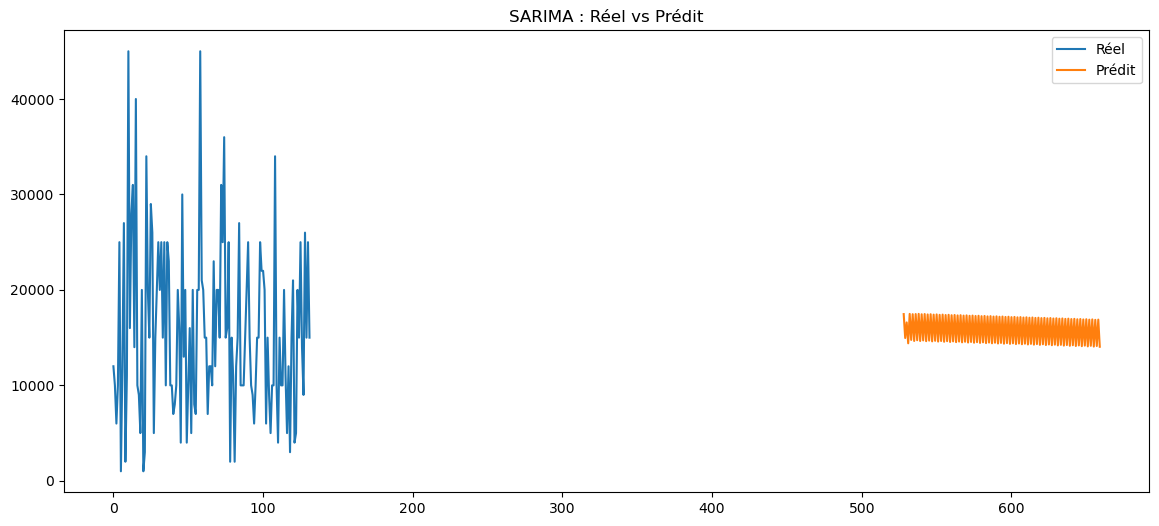

In [300]:
# REEL VS PREDIT

plt.figure(figsize=(14,6))

plt.plot(
    test.values,
    label="Réel"
)

plt.plot(
    predictions_sarima,
    label="Prédit"
)

plt.legend()

plt.title("SARIMA : Réel vs Prédit")

plt.show()

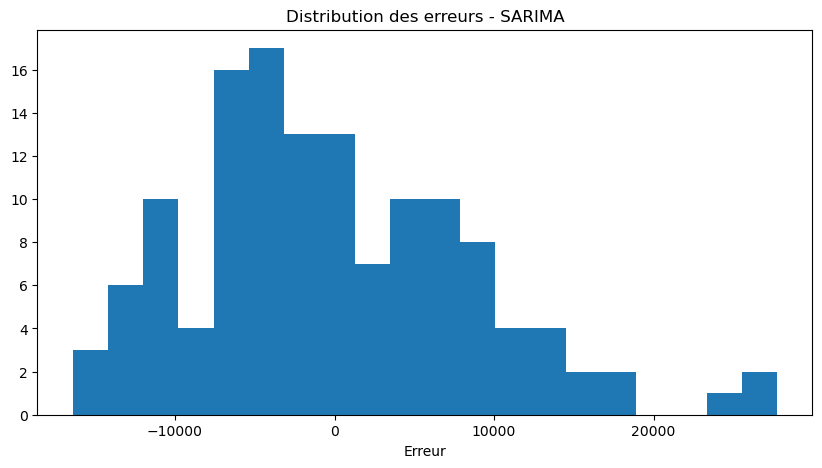

In [302]:
# DISTRIBUTION DES ERREURS

errors = test.values - predictions_sarima

plt.figure(figsize=(10,5))

plt.hist(errors, bins=20)

plt.title("Distribution des erreurs - SARIMA")

plt.xlabel("Erreur")

plt.show()

In [304]:

# COMPARAISON

comparaison = pd.DataFrame({
    "Modele": [
        "Random Forest",
        "XGBoost",
        "ARIMA",
        "SARIMA"
    ],

    "MAE": [
        2702.52,
        2756.39,
        3690.72,
        mae
    ],

    "RMSE": [
        3677.12,
        3808.61,
        5032.55,
        rmse
    ],

    "R2": [
        0.626,
        0.598,
        -0.006,
        r2
    ]
})

display(comparaison)

,Modele,MAE,RMSE,R2
0,Random Forest,2702.520000,3677.120000,0.626000
1,XGBoost,2756.390000,3808.610000,0.598000
2,ARIMA,3690.720000,5032.550000,-0.006000
3,SARIMA,7173.181165,8870.236274,0.011671


## 10. Sauvegarde du modèle

Le modèle pourra être :réutilisé, intégré dans Streamlit, déployé.

In [306]:
# SAUVEGARDE

import joblib

joblib.dump(
    model_arima,
    "arima_model.pkl"
)

joblib.dump(
    model_sarima,
    "sarima_model.pkl"
)

print("Modèles sauvegardés.")

Modèles sauvegardés.


## Conclusion générale des modèles ARIMA et SARIMA

Les modèles ARIMA et SARIMA ont été utilisés afin d’explorer les approches classiques de prévision des séries temporelles appliquées aux commandes de carburant des stations-service.

Les résultats obtenus montrent des performances variables selon :
- la station étudiée ;
- le produit considéré ;
- la régularité des comportements de commande.

Cette variation des performances indique que les séries temporelles des stations-service présentent des dynamiques très hétérogènes.

Certaines stations possèdent des comportements relativement stables et périodiques, permettant aux modèles ARIMA ou SARIMA de produire des prévisions acceptables. En revanche, d’autres stations présentent des fluctuations importantes, des variations brusques ainsi qu’une faible régularité temporelle, limitant fortement les capacités prédictives de ces modèles.

Les résultats obtenus montrent globalement que :
- les modèles ARIMA et SARIMA restent sensibles à la qualité et à la stabilité des séries temporelles ;
- les comportements de commande ne suivent pas toujours une structure statistique linéaire ou saisonnière claire ;
- les performances changent fortement selon les caractéristiques propres à chaque station et à chaque produit.

L’ajout de la composante saisonnière avec SARIMA n’a pas systématiquement permis d’améliorer les performances prédictives. Cela suggère que la saisonnalité des commandes n’est pas toujours stable ou suffisamment marquée dans les données étudiées.

Cette étude met également en évidence la complexité métier du problème de prévision des commandes pétrolières. Les quantités commandées semblent influencées non seulement par les historiques temporels, mais également par plusieurs facteurs externes tels que :
- les habitudes locales de consommation ;
- les niveaux de stock ;
- les ruptures d’approvisionnement ;
- les décisions opérationnelles ;
- les variations de la demande.

Ainsi, les modèles statistiques classiques présentent certaines limites face à la forte variabilité observée dans les données.

Les comparaisons réalisées avec les modèles de Machine Learning montrent que les approches telles que Random Forest et XGBoost offrent de meilleures performances globales. Ces modèles apparaissent plus adaptés pour capturer les relations complexes et non linéaires présentes dans les comportements de commande des stations-service.

Cependant, les modèles ARIMA et SARIMA conservent un intérêt scientifique important dans cette étude, car ils permettent :
- d’analyser la structure temporelle des données ;
- d’évaluer l’existence d’une saisonnalité ;
- de comparer les approches statistiques classiques aux méthodes modernes de Machine Learning.

En conclusion, cette phase expérimentale montre que la prévision des commandes de carburant constitue un problème complexe nécessitant des modèles capables d’intégrer simultanément :
- les dépendances temporelles ;
- les comportements saisonniers ;
- les variables métier ;
- ainsi que les interactions non linéaires entre les données.